In [ ]:
# =====================================================================
# ENVIRONMENT GUARD — run this cell first, before any TensorFlow import.
#
# This package requires Keras 2. Under Keras 3 the L1 activity regularizer
# on the autoencoder's latent layer drives it to zero: the model degenerates
# to predicting the per-feature mean and detects nothing. The failure is
# SILENT -- the healthy false-alarm rate still reads 2%.
#
# TensorFlow 2.16+ defaults to Keras 3, so tf-keras must be installed and
# TF_USE_LEGACY_KERAS set before TensorFlow is imported.
#
# See REPRODUCIBILITY.md, Section 0.
# =====================================================================

import os
import sys

os.environ["TF_USE_LEGACY_KERAS"] = "1"

# Make the modules in code/ importable regardless of the working directory.
sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")) or ".")

import tensorflow as tf

_keras_version = getattr(tf.keras, "__version__", None)
if _keras_version is None:
    import tf_keras
    _keras_version = tf_keras.__version__

print("TensorFlow", tf.__version__)
print("Keras     ", _keras_version)

if not str(_keras_version).startswith("2."):
    raise RuntimeError(
        f"Keras {_keras_version} is active, but this package requires Keras 2.\n"
        "Install it and restart the kernel:\n"
        "    pip install tf-keras\n"
        "Then re-run this cell before anything else.\n"
        "See REPRODUCIBILITY.md, Section 0."
    )

print("Keras 2 active - safe to proceed.")

# Bearing Autoencoder — PER ASSET EXPERIMENT

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import os
from pathlib import Path
from collections import deque

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from sklearn.svm import OneClassSVM
from sklearn.covariance import EllipticEnvelope

from sklearn.pipeline import Pipeline

import pandas as pd
import numpy as np

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model

GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)
tf.random.set_seed(GLOBAL_SEED)
print('TF version:', tf.__version__)

TF version: 2.16.2


In [3]:
# Dataset location is resolved by data_paths.py:
#   1. $CWRU_DATA_ROOT   2. <deposit>/data/CWRU   3. ../CWRU_Bearing_NumPy-main/Data
# See data/README.md. Raw data is not redistributed with this deposit.
from data_paths import cwru_root

data_root = cwru_root()
print("CWRU data root:", data_root)

In [4]:
def load_cwru_signal(bearing_id, regime):
    bearing_rpm = f"{bearing_id} RPM"
    folder = data_root / bearing_rpm

    if regime == "healthy":
        d = np.load(folder / f"{bearing_id}_Normal.npz")
        return d["DE"]

    patterns = {
        "ball":  f"{bearing_id}_B_*_DE12.npz",
        "inner": f"{bearing_id}_IR_*_DE12.npz",
        "outer": f"{bearing_id}_OR*@*_DE12.npz",
    }

    signals = []
    for f in sorted(folder.glob(patterns[regime])):
        d = np.load(f)
        signals.append(d["DE"])

    return np.concatenate(signals)

In [5]:
def make_windows(x, win=1200, step=1200):
    n = (len(x) - win) // step + 1
    return np.stack([x[i*step:i*step+win] for i in range(n)], axis=0)

# ── Compute CWRU MSEs first ─────────────────────────────────────────────
def cwru_mse(signal_1d):
    ws    = make_windows(signal_1d, win=1200, step=1200)
    ws_2d = ws.reshape(ws.shape[0], -1)
    ws_sc = scaler.transform(ws_2d)
    X     = ws_sc[:, :, np.newaxis].astype('float32')
    X_rec = ae.predict(X, verbose=0)
    return np.mean((X - X_rec)**2, axis=(1, 2))

In [6]:
BEARING_IDS = ("1730", "1750", "1772", "1797")
WIN = 1200
STEP = 1200
THRESHOLD_PERCENTILE = 98.0


def load_asset_windows(
    bearing_id: str,
    *,
    win: int = WIN,
    step: int = STEP,
):
    """
    Load and window CWRU exactly as in bearing_autoencoder.ipynb.

    No train/calibration/test split is introduced. This is the ideal,
    asset-specific oracle: all available healthy observations are used
    for model fitting and threshold calibration.
    """
    signals = {
        "healthy": load_cwru_signal(bearing_id, "healthy"),
        "ball": load_cwru_signal(bearing_id, "ball"),
        "inner_race": load_cwru_signal(bearing_id, "inner"),
        "outer_race": load_cwru_signal(bearing_id, "outer"),
    }

    return {
        regime: make_windows(
            signal,
            win=win,
            step=step,
        ).astype(np.float32)
        for regime, signal in signals.items()
    }


def evaluate_scores(
    *,
    bearing_id: str,
    detector_name: str,
    healthy_scores: np.ndarray,
    ball_scores: np.ndarray,
    inner_scores: np.ndarray,
    outer_scores: np.ndarray,
    threshold_percentile: float = THRESHOLD_PERCENTILE,
):
    """
    Common evaluation for all detectors.

    Larger score must always mean more anomalous.
    """
    tau = float(
        np.percentile(
            healthy_scores,
            threshold_percentile,
        )
    )

    return {
        "bearing_id": bearing_id,
        "detector": detector_name,
        "threshold_percentile": threshold_percentile,
        "threshold": tau,
        "healthy_far": 100.0 * np.mean(healthy_scores > tau),
        "ball_dr": 100.0 * np.mean(ball_scores > tau),
        "inner_race_dr": 100.0 * np.mean(inner_scores > tau),
        "outer_race_dr": 100.0 * np.mean(outer_scores > tau),
        "n_healthy": len(healthy_scores),
        "n_ball": len(ball_scores),
        "n_inner_race": len(inner_scores),
        "n_outer_race": len(outer_scores),
    }

#### TEST ONE-CLASS SVM

In [7]:
ocsvm_results = []

for bearing_id in BEARING_IDS:
    print(f"Running asset-specific OC-SVM for {bearing_id} RPM...")

    windows = load_asset_windows(bearing_id)

    # Asset-specific preprocessing fitted only on its real healthy data.
    scaler = StandardScaler()
    X_healthy_raw = windows["healthy"].reshape(len(windows["healthy"]), -1)
    X_ball_raw = windows["ball"].reshape(len(windows["ball"]), -1)
    X_inner_raw = windows["inner_race"].reshape(len(windows["inner_race"]), -1)
    X_outer_raw = windows["outer_race"].reshape(len(windows["outer_race"]), -1)

    scaler = StandardScaler()

    X_healthy = scaler.fit_transform(X_healthy_raw)
    X_ball = scaler.transform(X_ball_raw)
    X_inner = scaler.transform(X_inner_raw)
    X_outer = scaler.transform(X_outer_raw)

    # PCA is trained only on this asset's healthy observations.
    # It prevents the RBF OC-SVM from operating directly in 1200 dimensions.
    n_components = min(
        32,
        X_healthy.shape[0] - 1,
        X_healthy.shape[1],
    )

    detector = Pipeline(
        [
            (
                "pca",
                PCA(
                    n_components=n_components,
                    random_state=GLOBAL_SEED,
                ),
            ),
            (
                "ocsvm",
                OneClassSVM(
                    kernel="rbf",
                    nu=0.02,
                    gamma="scale",
                ),
            ),
        ]
    )

    detector.fit(X_healthy)

    # sklearn returns larger score_samples for more nominal samples.
    # Negate so that larger always means more anomalous.
    healthy_scores = -detector.score_samples(X_healthy)
    ball_scores = -detector.score_samples(X_ball)
    inner_scores = -detector.score_samples(X_inner)
    outer_scores = -detector.score_samples(X_outer)

    ocsvm_results.append(
        evaluate_scores(
            bearing_id=bearing_id,
            detector_name="Asset-specific OC-SVM",
            healthy_scores=healthy_scores,
            ball_scores=ball_scores,
            inner_scores=inner_scores,
            outer_scores=outer_scores,
        )
    )

ocsvm_results = pd.DataFrame(ocsvm_results)
display(ocsvm_results)

Running asset-specific OC-SVM for 1730 RPM...
Running asset-specific OC-SVM for 1750 RPM...
Running asset-specific OC-SVM for 1772 RPM...
Running asset-specific OC-SVM for 1797 RPM...


,bearing_id,detector,threshold_percentile,threshold,healthy_far,ball_dr,inner_race_dr,outer_race_dr,n_healthy,n_ball,n_inner_race,n_outer_race
0,1730,Asset-specific OC-SVM,98.0,-0.999212,2.227723,0.000000,25.123153,4.915730,404,405,406,712
1,1750,Asset-specific OC-SVM,98.0,-1.069604,2.227723,12.345679,25.185185,5.907173,404,405,405,711
2,1772,Asset-specific OC-SVM,98.0,-0.953015,2.233251,0.000000,24.938272,0.000000,403,405,405,712
3,1797,Asset-specific OC-SVM,98.0,-0.604553,2.463054,0.000000,24.938272,0.000000,203,406,405,711


#### TEST ELLIPTICAL ENVELOPE

In [8]:
elliptic_results = []

for bearing_id in BEARING_IDS:
    print(f"Running asset-specific Elliptic Envelope for {bearing_id} RPM...")

    windows = load_asset_windows(bearing_id)

    # Flatten exactly as for OC-SVM
    X_healthy_raw = windows["healthy"].reshape(len(windows["healthy"]), -1)
    X_ball_raw = windows["ball"].reshape(len(windows["ball"]), -1)
    X_inner_raw = windows["inner_race"].reshape(len(windows["inner_race"]), -1)
    X_outer_raw = windows["outer_race"].reshape(len(windows["outer_race"]), -1)

    # Asset-specific preprocessing fitted only on real healthy data
    scaler = StandardScaler()

    X_healthy = scaler.fit_transform(X_healthy_raw)
    X_ball = scaler.transform(X_ball_raw)
    X_inner = scaler.transform(X_inner_raw)
    X_outer = scaler.transform(X_outer_raw)

    # Robust covariance estimation is unstable in 1200-D with only a few
    # hundred healthy windows, so reduce dimensionality using healthy-only PCA.
    n_components = min(
        16,
        X_healthy.shape[0] - 1,
        X_healthy.shape[1],
    )

    detector = Pipeline(
        [
            (
                "pca",
                PCA(
                    n_components=n_components,
                    random_state=GLOBAL_SEED,
                ),
            ),
            (
                "elliptic",
                EllipticEnvelope(
                    contamination=0.02,
                    support_fraction=None,
                    random_state=GLOBAL_SEED,
                ),
            ),
        ]
    )

    detector.fit(X_healthy)

    # sklearn score_samples:
    # larger = more nominal
    # negate so larger = more anomalous
    healthy_scores = -detector.score_samples(X_healthy)
    ball_scores = -detector.score_samples(X_ball)
    inner_scores = -detector.score_samples(X_inner)
    outer_scores = -detector.score_samples(X_outer)

    elliptic_results.append(
        evaluate_scores(
            bearing_id=bearing_id,
            detector_name="Asset-specific Elliptic Envelope",
            healthy_scores=healthy_scores,
            ball_scores=ball_scores,
            inner_scores=inner_scores,
            outer_scores=outer_scores,
        )
    )

elliptic_results = pd.DataFrame(elliptic_results)
display(elliptic_results)

Running asset-specific Elliptic Envelope for 1730 RPM...
Running asset-specific Elliptic Envelope for 1750 RPM...
Running asset-specific Elliptic Envelope for 1772 RPM...
Running asset-specific Elliptic Envelope for 1797 RPM...


,bearing_id,detector,threshold_percentile,threshold,healthy_far,ball_dr,inner_race_dr,outer_race_dr,n_healthy,n_ball,n_inner_race,n_outer_race
0,1730,Asset-specific Elliptic Envelope,98.0,26.031561,2.227723,0.000000,25.369458,6.460674,404,405,406,712
1,1750,Asset-specific Elliptic Envelope,98.0,32.522446,2.227723,2.469136,17.777778,0.562588,404,405,405,711
2,1772,Asset-specific Elliptic Envelope,98.0,39.481334,2.233251,0.000000,0.000000,0.000000,403,405,405,712
3,1797,Asset-specific Elliptic Envelope,98.0,68.972761,2.463054,0.000000,14.567901,0.000000,203,406,405,711


In [9]:
LATENT_DIM = 16
SIG_LEN = 1200

def build_autoencoder(sig_len, latent_dim):
    # ── Encoder ──────────────────────────────────────────────────────────
    inp = keras.Input(shape=(sig_len, 1), name='signal_in')
    x = layers.Conv1D(32,  kernel_size=16, strides=2, padding='same', activation='relu')(inp)
    x = layers.Conv1D(64,  kernel_size=8,  strides=2, padding='same', activation='relu')(x)
    x = layers.Conv1D(128, kernel_size=4,  strides=2, padding='same', activation='relu')(x)
    conv_shape = x.shape[1:]            # remember shape before flatten
    x = layers.Flatten()(x)
    latent = layers.Dense(
        latent_dim,
        activity_regularizer=keras.regularizers.l1(1.5e-4),
        name='latent'
    )(x)


    # ── Decoder ──────────────────────────────────────────────────────────
    y = layers.Dense(conv_shape[0] * conv_shape[1], activation='relu')(latent)
    y = layers.Reshape(conv_shape)(y)
    y = layers.Conv1DTranspose(128, kernel_size=4,  strides=2, padding='same', activation='relu')(y)
    y = layers.Conv1DTranspose(64,  kernel_size=8,  strides=2, padding='same', activation='relu')(y)
    y = layers.Conv1DTranspose(32,  kernel_size=16, strides=2, padding='same', activation='relu')(y)
    # Final layer: crop or pad to exact sig_len, linear activation
    y = layers.Conv1D(1, kernel_size=1, padding='same', activation='linear', name='signal_out')(y)
    y = layers.Cropping1D((0, y.shape[1] - sig_len))(y) if y.shape[1] > sig_len else y

    autoencoder = Model(inp, y, name='bearing_autoencoder')
    encoder     = Model(inp, latent, name='encoder')
    return autoencoder, encoder

ae, encoder = build_autoencoder(SIG_LEN, LATENT_DIM)
ae.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')
ae.summary()

2026-07-27 13:34:38.540233: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Pro
2026-07-27 13:34:38.540405: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-07-27 13:34:38.540426: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-07-27 13:34:38.540501: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-07-27 13:34:38.540534: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "bearing_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ signal_in (InputLayer)          │ (None, 1200, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 600, 32)        │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 300, 64)        │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 150, 128)       │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 19200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 16)             │       307,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 19200)          │       326,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 150, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose                │ (None, 300, 128)       │        65,664 │
│ (Conv1DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose_1              │ (None, 600, 64)        │        65,600 │
│ (Conv1DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose_2              │ (None, 1200, 32)       │        32,800 │
│ (Conv1DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ signal_out (Conv1D)             │ (None, 1200, 1)        │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 847,601 (3.23 MB)

 Trainable params: 847,601 (3.23 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
STABILITY_SEEDS = [7, 21, 42, 84, 126]

ae_results = []

for seed in STABILITY_SEEDS:

    print(f"\n==========================")
    print(f"Seed {seed}")
    print(f"==========================")

    keras.backend.clear_session()

    np.random.seed(seed)
    tf.random.set_seed(seed)

    try:
        keras.utils.set_random_seed(seed)
    except Exception:
        pass

    for bearing_id in BEARING_IDS:

        print(f"Training asset-specific AE for {bearing_id} RPM...")

        windows = load_asset_windows(bearing_id)

        # -------------------------------------------------------
        # preprocessing
        # -------------------------------------------------------

        X_healthy_raw = windows["healthy"].reshape(len(windows["healthy"]), -1)
        X_ball_raw = windows["ball"].reshape(len(windows["ball"]), -1)
        X_inner_raw = windows["inner_race"].reshape(len(windows["inner_race"]), -1)
        X_outer_raw = windows["outer_race"].reshape(len(windows["outer_race"]), -1)

        scaler = StandardScaler()

        X_healthy_sc = scaler.fit_transform(X_healthy_raw).astype(np.float32)
        X_ball_sc = scaler.transform(X_ball_raw).astype(np.float32)
        X_inner_sc = scaler.transform(X_inner_raw).astype(np.float32)
        X_outer_sc = scaler.transform(X_outer_raw).astype(np.float32)

        X_healthy = X_healthy_sc[..., np.newaxis]
        X_ball = X_ball_sc[..., np.newaxis]
        X_inner = X_inner_sc[..., np.newaxis]
        X_outer = X_outer_sc[..., np.newaxis]

        # -------------------------------------------------------
        # model
        # -------------------------------------------------------

        ae, encoder = build_autoencoder(
            sig_len=X_healthy.shape[1],
            latent_dim=LATENT_DIM,
        )

        ae.compile(
            optimizer=keras.optimizers.Adam(1e-3),
            loss="mse",
        )

        callbacks = [
            keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=10,
                restore_best_weights=True,
            ),
            keras.callbacks.ReduceLROnPlateau(
                monitor="val_loss",
                factor=0.5,
                patience=5,
                min_lr=1e-5,
            ),
        ]

        ae.fit(
            X_healthy,
            X_healthy,
            validation_split=0.20,
            epochs=100,
            batch_size=32,
            shuffle=True,
            callbacks=callbacks,
            verbose=0,
        )

        # -------------------------------------------------------
        # scores
        # -------------------------------------------------------

        healthy_rec = ae.predict(X_healthy, verbose=0)
        ball_rec = ae.predict(X_ball, verbose=0)
        inner_rec = ae.predict(X_inner, verbose=0)
        outer_rec = ae.predict(X_outer, verbose=0)

        healthy_scores = np.mean((X_healthy - healthy_rec) ** 2, axis=(1, 2))
        ball_scores    = np.mean((X_ball    - ball_rec)    ** 2, axis=(1, 2))
        inner_scores   = np.mean((X_inner   - inner_rec)   ** 2, axis=(1, 2))
        outer_scores   = np.mean((X_outer   - outer_rec)   ** 2, axis=(1, 2))

        row = evaluate_scores(
            bearing_id=bearing_id,
            detector_name="Asset-specific AE",
            healthy_scores=healthy_scores,
            ball_scores=ball_scores,
            inner_scores=inner_scores,
            outer_scores=outer_scores,
        )

        row["seed"] = seed

        ae_results.append(row)

# -------------------------------------------------------
# final dataframe
# -------------------------------------------------------

ae_results = pd.DataFrame(ae_results)

display(ae_results)


Seed 7
Training asset-specific AE for 1730 RPM...


2026-07-27 13:34:39.926354: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


Training asset-specific AE for 1750 RPM...
Training asset-specific AE for 1772 RPM...
Training asset-specific AE for 1797 RPM...

Seed 21
Training asset-specific AE for 1730 RPM...
Training asset-specific AE for 1750 RPM...
Training asset-specific AE for 1772 RPM...
Training asset-specific AE for 1797 RPM...

Seed 42
Training asset-specific AE for 1730 RPM...
Training asset-specific AE for 1750 RPM...
Training asset-specific AE for 1772 RPM...
Training asset-specific AE for 1797 RPM...

Seed 84
Training asset-specific AE for 1730 RPM...
Training asset-specific AE for 1750 RPM...
Training asset-specific AE for 1772 RPM...
Training asset-specific AE for 1797 RPM...

Seed 126
Training asset-specific AE for 1730 RPM...
Training asset-specific AE for 1750 RPM...
Training asset-specific AE for 1772 RPM...
Training asset-specific AE for 1797 RPM...


,bearing_id,detector,threshold_percentile,threshold,healthy_far,ball_dr,inner_race_dr,outer_race_dr,n_healthy,n_ball,n_inner_race,n_outer_race,seed
0,1730,Asset-specific AE,98.0,0.658501,2.227723,100.0,100.0,100.0,404,405,406,712,7
1,1750,Asset-specific AE,98.0,0.666244,2.227723,100.0,100.0,100.0,404,405,405,711,7
2,1772,Asset-specific AE,98.0,0.883316,2.233251,100.0,100.0,100.0,403,405,405,712,7
3,1797,Asset-specific AE,98.0,0.446139,2.463054,100.0,100.0,100.0,203,406,405,711,7
4,1730,Asset-specific AE,98.0,0.672507,2.227723,100.0,100.0,100.0,404,405,406,712,21
5,1750,Asset-specific AE,98.0,1.164796,2.227723,100.0,100.0,100.0,404,405,405,711,21
6,1772,Asset-specific AE,98.0,0.610576,2.233251,100.0,100.0,100.0,403,405,405,712,21
7,1797,Asset-specific AE,98.0,0.473301,2.463054,100.0,100.0,100.0,203,406,405,711,21
8,1730,Asset-specific AE,98.0,0.619351,2.227723,100.0,100.0,100.0,404,405,406,712,42
9,1750,Asset-specific AE,98.0,0.656872,2.227723,100.0,100.0,100.0,404,405,405,711,42


In [11]:
stability = (
    ae_results
    .groupby("bearing_id")
    .agg(
        healthy_far_mean=("healthy_far", "mean"),
        healthy_far_std=("healthy_far", "std"),
        ball_dr_mean=("ball_dr", "mean"),
        ball_dr_std=("ball_dr", "std"),
        inner_race_dr_mean=("inner_race_dr", "mean"),
        inner_race_dr_std=("inner_race_dr", "std"),
        outer_race_dr_mean=("outer_race_dr", "mean"),
        outer_race_dr_std=("outer_race_dr", "std"),
        threshold_mean=("threshold", "mean"),
        threshold_std=("threshold", "std"),
    )
    .reset_index()
)

display(stability)

,bearing_id,healthy_far_mean,healthy_far_std,ball_dr_mean,ball_dr_std,inner_race_dr_mean,inner_race_dr_std,outer_race_dr_mean,outer_race_dr_std,threshold_mean,threshold_std
0,1730,2.227723,0.0,100.0,0.0,100.0,0.0,100.0,0.0,0.648529,0.020741
1,1750,2.227723,0.0,100.0,0.0,100.0,0.0,100.0,0.0,0.759031,0.226892
2,1772,2.233251,0.0,100.0,0.0,100.0,0.0,100.0,0.0,0.724833,0.148432
3,1797,2.463054,0.0,100.0,0.0,100.0,0.0,100.0,0.0,0.459058,0.026359


### METHOD TEST

In [12]:
# =====================================================================
# TRAIN THE FIXED OEM / SHARED SIMULATOR-TRAINED MODEL
# =====================================================================

from bearing_simulator import CWRU_PARAMS, BearingSignalSimulator

# ---------------------------------------------------------------------
# Reproducibility
# ---------------------------------------------------------------------

OEM_SEED = 42

keras.backend.clear_session()
keras.utils.set_random_seed(OEM_SEED)
np.random.seed(OEM_SEED)
tf.random.set_seed(OEM_SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass


# ---------------------------------------------------------------------
# Synthetic dataset configuration
# ---------------------------------------------------------------------

shared_simulator = BearingSignalSimulator(CWRU_PARAMS)
shared_sig_len = len(shared_simulator.t)

SYNTHETIC_REGIMES = [
    "healthy",
    "outer_race",
    "inner_race",
    "ball_fault",
]

SYNTHETIC_LABELS = {
    "healthy": 0,
    "outer_race": 1,
    "inner_race": 2,
    "ball_fault": 3,
}

N_SYNTHETIC_TRAIN = 4_000
N_SYNTHETIC_VAL = 1_000
N_SYNTHETIC_TEST = 750

SHARED_LATENT_DIM = 16
SHARED_THRESHOLD_PERCENTILE = 98.0

print(f"Shared synthetic signal length: {shared_sig_len} samples")


# ---------------------------------------------------------------------
# Generate independent healthy training and validation datasets
# ---------------------------------------------------------------------

X_shared_train_raw = np.asarray(
    [
        shared_simulator.sample("healthy", mc=True)
        for _ in range(N_SYNTHETIC_TRAIN)
    ],
    dtype=np.float32,
)

X_shared_val_raw = np.asarray(
    [
        shared_simulator.sample("healthy", mc=True)
        for _ in range(N_SYNTHETIC_VAL)
    ],
    dtype=np.float32,
)


# ---------------------------------------------------------------------
# Fit preprocessing only on synthetic healthy training data
# ---------------------------------------------------------------------

shared_scaler = StandardScaler()

X_shared_train_sc = shared_scaler.fit_transform(
    X_shared_train_raw
).astype(np.float32)

X_shared_val_sc = shared_scaler.transform(
    X_shared_val_raw
).astype(np.float32)

X_shared_train = X_shared_train_sc[..., np.newaxis]
X_shared_val = X_shared_val_sc[..., np.newaxis]


# ---------------------------------------------------------------------
# Generate a separate synthetic test set
# ---------------------------------------------------------------------

shared_test_by_regime = {}
shared_y_test_parts = []

for regime in SYNTHETIC_REGIMES:
    regime_raw = np.asarray(
        [
            shared_simulator.sample(regime, mc=True)
            for _ in range(N_SYNTHETIC_TEST)
        ],
        dtype=np.float32,
    )

    regime_sc = shared_scaler.transform(
        regime_raw
    ).astype(np.float32)

    shared_test_by_regime[regime] = regime_sc[..., np.newaxis]

    shared_y_test_parts.append(
        np.full(
            N_SYNTHETIC_TEST,
            SYNTHETIC_LABELS[regime],
            dtype=np.int64,
        )
    )

X_shared_test = np.concatenate(
    [
        shared_test_by_regime[regime]
        for regime in SYNTHETIC_REGIMES
    ],
    axis=0,
)

y_shared_test = np.concatenate(
    shared_y_test_parts,
    axis=0,
)

print(
    f"Train: {X_shared_train.shape} | "
    f"Validation: {X_shared_val.shape} | "
    f"Test: {X_shared_test.shape}"
)


# ---------------------------------------------------------------------
# Build and train the fixed shared/OEM autoencoder
# ---------------------------------------------------------------------

shared_ae, shared_encoder = build_autoencoder(
    sig_len=shared_sig_len,
    latent_dim=SHARED_LATENT_DIM,
)

shared_ae.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
)

shared_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
    ),
]

shared_history = shared_ae.fit(
    X_shared_train,
    X_shared_train,
    validation_data=(X_shared_val, X_shared_val),
    epochs=100,
    batch_size=32,
    shuffle=True,
    callbacks=shared_callbacks,
    verbose=1,
)


# ---------------------------------------------------------------------
# Calibrate the simulator threshold on held-out healthy validation data
# ---------------------------------------------------------------------

X_shared_val_rec = shared_ae.predict(
    X_shared_val,
    verbose=0,
)

shared_val_mse = np.mean(
    np.square(X_shared_val - X_shared_val_rec),
    axis=(1, 2),
)

shared_tau_mc = float(
    np.percentile(
        shared_val_mse,
        SHARED_THRESHOLD_PERCENTILE,
    )
)

print(
    f"\nSynthetic validation threshold "
    f"τ_MC (p{SHARED_THRESHOLD_PERCENTILE:.0f}) "
    f"= {shared_tau_mc:.6f}"
)


# ---------------------------------------------------------------------
# Evaluate on the independent synthetic test set
# ---------------------------------------------------------------------

X_shared_test_rec = shared_ae.predict(
    X_shared_test,
    verbose=0,
)

shared_test_mse = np.mean(
    np.square(X_shared_test - X_shared_test_rec),
    axis=(1, 2),
)


def _synthetic_rate(regime: str) -> float:
    regime_mask = (
        y_shared_test == SYNTHETIC_LABELS[regime]
    )

    return 100.0 * float(
        np.mean(
            shared_test_mse[regime_mask] > shared_tau_mc
        )
    )


synthetic_ae_results = pd.DataFrame(
    [
        {
            "bearing_id": "Synthetic",
            "detector": "Shared simulator-trained AE",
            "threshold_percentile": SHARED_THRESHOLD_PERCENTILE,
            "threshold": shared_tau_mc,
            "healthy_far": _synthetic_rate("healthy"),
            "ball_dr": _synthetic_rate("ball_fault"),
            "inner_race_dr": _synthetic_rate("inner_race"),
            "outer_race_dr": _synthetic_rate("outer_race"),
            "n_healthy": N_SYNTHETIC_TEST,
            "n_ball": N_SYNTHETIC_TEST,
            "n_inner_race": N_SYNTHETIC_TEST,
            "n_outer_race": N_SYNTHETIC_TEST,
            "training_seed": OEM_SEED,
            "n_train": N_SYNTHETIC_TRAIN,
            "n_validation": N_SYNTHETIC_VAL,
        }
    ]
)

display(synthetic_ae_results)


# ---------------------------------------------------------------------
# Sanity checks
# ---------------------------------------------------------------------

assert shared_ae is not None
assert shared_scaler is not None
assert shared_sig_len == X_shared_train.shape[1]
assert np.isfinite(shared_tau_mc)

print("\nFixed OEM artifacts created:")
print("  shared_ae")
print("  shared_encoder")
print("  shared_scaler")
print("  shared_tau_mc")
print("  shared_history")

Shared synthetic signal length: 1200 samples
Train: (4000, 1200, 1) | Validation: (1000, 1200, 1) | Test: (3000, 1200, 1)
Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - loss: 0.2822 - val_loss: 0.0907 - learning_rate: 0.0010
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.0776 - val_loss: 0.0707 - learning_rate: 0.0010
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 0.0690 - val_loss: 0.0703 - learning_rate: 0.0010
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 0.0688 - val_loss: 0.0696 - learning_rate: 0.0010
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 0.0682 - val_loss: 0.0682 - learning_rate: 0.0010
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 0.0670 - val_loss: 0.0671 - learning_rate: 0.0010
Epoch 7/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - loss: 0.0655 - val_loss: 0.0662 - learning_rate: 0.0010
Epoch 8/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 0.0669 - val_loss: 0.0662 - lear

,bearing_id,detector,threshold_percentile,threshold,healthy_far,ball_dr,inner_race_dr,outer_race_dr,n_healthy,n_ball,n_inner_race,n_outer_race,training_seed,n_train,n_validation
0,Synthetic,Shared simulator-trained AE,98.0,0.102678,1.333333,95.6,100.0,100.0,750,750,750,750,42,4000,1000



Fixed OEM artifacts created:
  shared_ae
  shared_encoder
  shared_scaler
  shared_tau_mc
  shared_history


### DOMAIN ADAPTATION ###

In [13]:
TARGET_PERCENTILE = 98.0
WARMUP_SIZE = 100
WINDOW_SIZE = 100
MIN_WARMUP_SAMPLES = 20

MIN_CALIBRATION_SIZE = 40
MAX_CALIBRATION_SIZE = 200

CONVERGENCE_LOOKBACK = 10
CONVERGENCE_TOLERANCE = 0.01
CONVERGENCE_CONSECUTIVE = 10

In [26]:
# =====================================================================
# Online operational-radius estimator and convergence utilities
#
# These were previously defined inline here and duplicated between the CWRU
# and NASA IMS notebooks. They now live in code/operational_radius.py so both
# notebooks share one definition. Behaviour is unchanged.
# =====================================================================

from operational_radius import (
    AdaptiveOperationalRadius,
    operational_radius_convergence_trace,
    find_convergence_index,
)


# =====================================================================
# Shared simulator-trained AE applied unchanged to CWRU
# =====================================================================

def run_experiment(
    bearing_id,
    *,
    target_percentile=TARGET_PERCENTILE,
    min_calibration_size=MIN_CALIBRATION_SIZE,
    max_calibration_size=MAX_CALIBRATION_SIZE,
    min_warmup_samples=MIN_WARMUP_SAMPLES,
    convergence_lookback=10,
    convergence_tolerance=0.01,
    convergence_consecutive=10,
):
    """
    Evaluate the simulator-trained shared AE on one CWRU condition.

    Important
    ---------
    - `ae` and `scaler` are the models trained on synthetic healthy data.
    - They are transferred unchanged to CWRU.
    - All CWRU healthy windows are used only for the field-oracle p98.
    - Calibration starts after `min_calibration_size` observations and
  continues until convergence is detected or `max_calibration_size`
  observations have been processed.
    """

    # -----------------------------------------------------------------
    # Load complete CWRU signals
    # -----------------------------------------------------------------

    normal_signal = load_cwru_signal(bearing_id, "healthy")
    ball_signal   = load_cwru_signal(bearing_id, "ball")
    inner_signal  = load_cwru_signal(bearing_id, "inner")
    outer_signal  = load_cwru_signal(bearing_id, "outer")

    print(f"\nCWRU operating condition: {bearing_id} RPM")
    print("Normal:", normal_signal.shape)
    print("Ball:  ", ball_signal.shape)
    print("Inner: ", inner_signal.shape)
    print("Outer: ", outer_signal.shape)

    # -----------------------------------------------------------------
    # Apply synthetic scaler and shared AE unchanged
    # -----------------------------------------------------------------

    def cwru_mse(signal):
        windows = make_windows(
            signal,
            win=shared_sig_len,
            step=shared_sig_len,
        )

        windows_2d = windows.reshape(
            windows.shape[0],
            -1,
        )

        # This scaler was fitted on synthetic nominal data.
        windows_scaled = shared_scaler.transform(
            windows_2d
        )

        X = windows_scaled[
            :,
            :,
            np.newaxis,
        ].astype(np.float32)

        X_rec = shared_ae.predict(
            X,
            verbose=0,
        )

        return np.mean(
            np.square(X - X_rec),
            axis=(1, 2),
        )

    # -----------------------------------------------------------------
    # Synthetic absolute threshold
    # -----------------------------------------------------------------

    tau_mc = float(shared_tau_mc)

    # -----------------------------------------------------------------
    # CWRU residuals
    # -----------------------------------------------------------------

    mse_healthy = cwru_mse(normal_signal)
    mse_ball = cwru_mse(ball_signal)
    mse_inner = cwru_mse(inner_signal)
    mse_outer = cwru_mse(outer_signal)

    print(
        "Windows → "
        f"healthy:{len(mse_healthy)} "
        f"ball:{len(mse_ball)} "
        f"inner:{len(mse_inner)} "
        f"outer:{len(mse_outer)}"
    )

    # -----------------------------------------------------------------
    # Field oracle: all available healthy CWRU windows
    # -----------------------------------------------------------------

    tau_field_oracle = float(
        np.percentile(
            mse_healthy,
            target_percentile,
        )
    )



    # -----------------------------------------------------------------
    # Adaptive field calibration: continue until convergence or N_max
    # -----------------------------------------------------------------

    min_calibration_size = int(min_calibration_size)

    max_calibration_size = min(
        int(max_calibration_size),
        len(mse_healthy),
    )

    if min_calibration_size < min_warmup_samples:
        raise ValueError(
            "min_calibration_size cannot be smaller than "
            "min_warmup_samples."
        )

    if min_calibration_size > max_calibration_size:
        raise ValueError(
            "min_calibration_size cannot exceed max_calibration_size."
        )

    mse_warmup = mse_healthy[:max_calibration_size]

    adaptive = AdaptiveOperationalRadius(
        percentile=target_percentile,
        window_size=max_calibration_size,
        min_samples=min_warmup_samples,
    )

    tau_history = adaptive.warmup_trace(
        mse_warmup
    )

    valid_tau = tau_history[
        np.isfinite(tau_history)
    ]

    if len(valid_tau) == 0:
        raise RuntimeError(
            "The online operational radius did not initialize."
        )

    convergence_index = find_convergence_index(
            tau_history,
            lookback=convergence_lookback,
            tolerance=convergence_tolerance,
            consecutive=convergence_consecutive,
            min_index=min_calibration_size - 1,
        )

    if convergence_index is None:
        convergence_window = np.nan
        calibration_size = max_calibration_size
        tau_online = np.nan
        calibration_status = "not_converged"

    else:
        convergence_window = convergence_index + 1
        calibration_size = convergence_window
        tau_online = float(tau_history[convergence_index])
        calibration_status = "converged"

    # -----------------------------------------------------------------
    # Metrics
    # -----------------------------------------------------------------

    def alarm_rate(scores, threshold):
        if not np.isfinite(threshold):
            return np.nan

        return 100.0 * float(
            np.mean(scores > threshold)
        )

    thresholds = {
        "absolute_mc": tau_mc,
        "field_oracle": tau_field_oracle,
    }

    if calibration_status == "converged":
        thresholds["online_radius"] = tau_online

    rows = []

    for threshold_name, threshold_value in thresholds.items():

        if threshold_name == "absolute_mc":
            threshold_calibration_size = 0
            threshold_convergence_index = np.nan
            threshold_convergence_window = np.nan
            threshold_calibration_status = "not_applicable"

        elif threshold_name == "field_oracle":
            threshold_calibration_size = len(mse_healthy)
            threshold_convergence_index = np.nan
            threshold_convergence_window = np.nan
            threshold_calibration_status = "oracle"

        else:
            threshold_calibration_size = calibration_size
            threshold_convergence_index = (
                convergence_index
                if convergence_index is not None
                else np.nan
            )
            threshold_convergence_window = (
                convergence_window
                if convergence_index is not None
                else np.nan
            )
            threshold_calibration_status = calibration_status

        rows.append(
            {
                "bearing_id": str(bearing_id),
                "detector": "Shared simulator-trained AE",
                "calibration": threshold_name,
                "threshold_percentile": target_percentile,
                "threshold": threshold_value,

                "healthy_far": alarm_rate(
                    mse_healthy,
                    threshold_value,
                ),
                "ball_dr": alarm_rate(
                    mse_ball,
                    threshold_value,
                ),
                "inner_race_dr": alarm_rate(
                    mse_inner,
                    threshold_value,
                ),
                "outer_race_dr": alarm_rate(
                    mse_outer,
                    threshold_value,
                ),

                "n_healthy": len(mse_healthy),
                "n_ball": len(mse_ball),
                "n_inner_race": len(mse_inner),
                "n_outer_race": len(mse_outer),

                "min_calibration_size": (
                    min_calibration_size
                    if threshold_name == "online_radius"
                    else np.nan
                ),
                "max_calibration_size": (
                    max_calibration_size
                    if threshold_name == "online_radius"
                    else np.nan
                ),
                "calibration_size": threshold_calibration_size,
                "calibration_status": threshold_calibration_status,
                "convergence_index": threshold_convergence_index,
                "convergence_window": threshold_convergence_window,
            }
        )

    results_table = pd.DataFrame(rows)

    print("\nThresholds")
    print(f"τ_MC absolute        = {tau_mc:.6f}")
    print(f"τ_field oracle p98   = {tau_field_oracle:.6f}")
    print(f"τ_online             = {tau_online:.6f}")
    print(f"Calibration status   = {calibration_status}")
    print(f"Calibration samples  = {calibration_size}")

    if convergence_index is None:
        print(
            "Operational-radius convergence was not detected "
            f"within N_max={max_calibration_size} windows."
        )
    else:
        print(
            "Operational-radius convergence detected at "
            f"calibration window {convergence_window}."
        )

    display(results_table)

    return {
        "bearing_id": str(bearing_id),

        "mse_healthy": mse_healthy,
        "mse_ball": mse_ball,
        "mse_inner": mse_inner,
        "mse_outer": mse_outer,

        "mse_warmup": mse_warmup,
        "tau_history": tau_history,

        "tau_mc": tau_mc,
        "tau_field_oracle": tau_field_oracle,
        "tau_online": tau_online,

        "min_calibration_size": min_calibration_size,
        "max_calibration_size": max_calibration_size,
        "calibration_size": calibration_size,
        "calibration_status": calibration_status,

        "convergence_index": convergence_index,
        "convergence_window": convergence_window,

        "results_table": results_table,
    }


# =====================================================================
# Plotting
# =====================================================================

def plot_experiment(result):
    """
    Plot field residual distribution and online radius convergence.
    """

    bearing_id = result["bearing_id"]

    mse_healthy = result["mse_healthy"]
    mse_warmup = result["mse_warmup"]

    tau_mc = result["tau_mc"]
    tau_field_oracle = result["tau_field_oracle"]
    tau_online = result["tau_online"]

    tau_history = result["tau_history"]
    convergence_index = result["convergence_index"]

    # -----------------------------------------------------------------
    # Healthy residual distribution
    # -----------------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(10, 5)
    )

    ax.hist(
        mse_healthy,
        bins=50,
        density=True,
        alpha=0.60,
        label="Healthy CWRU",
    )

    ax.axvline(
        tau_mc,
        linestyle="--",
        linewidth=1.5,
        label=f"Absolute simulator τ = {tau_mc:.4f}",
    )

    ax.axvline(
        tau_field_oracle,
        linestyle="--",
        linewidth=1.5,
        label=f"Field oracle p98 = {tau_field_oracle:.4f}",
    )

    ax.axvline(
        tau_online,
        linestyle="--",
        linewidth=1.5,
        label=f"Online radius = {tau_online:.4f}",
    )

    ax.set_xlabel("Reconstruction MSE")
    ax.set_ylabel("Density")
    ax.set_title(
        f"Healthy CWRU residual distribution — {bearing_id} RPM"
    )

    ax.legend()
    ax.grid(
        True,
        alpha=0.25,
        axis="y",
    )

    plt.tight_layout()
    plt.show()

    # -----------------------------------------------------------------
    # Operational-radius convergence
    # -----------------------------------------------------------------

    calibration_size = int(result["calibration_size"])
    calibration_status = result["calibration_status"]
    convergence_window = result["convergence_window"]

    # One-based operational window numbers
    steps = np.arange(1, len(tau_history) + 1)

    fig, ax = plt.subplots(figsize=(11, 5))

    if calibration_status == "converged":
        # Operationally used trajectory
        ax.plot(
            steps[:calibration_size],
            tau_history[:calibration_size],
            linewidth=1.7,
            label="Online radius during calibration",
        )

        # Retrospective continuation only
        if calibration_size < len(tau_history):
            ax.plot(
                steps[calibration_size - 1:],
                tau_history[calibration_size - 1:],
                linewidth=1.2,
                alpha=0.55,
                label="Retrospective continuation",
            )

        ax.axvline(
            convergence_window,
            linestyle=":",
            linewidth=1.3,
            label=f"Convergence = {int(convergence_window)}",
        )

        ax.scatter(
            convergence_window,
            tau_online,
            s=35,
            zorder=5,
        )

    else:
        ax.plot(
            steps,
            tau_history,
            linewidth=1.5,
            label="Online operational radius",
        )

    ax.axhline(
        tau_field_oracle,
        linestyle="--",
        linewidth=1.2,
        label=f"Full-data field oracle = {tau_field_oracle:.4f}",
    )

    ax.axhline(
        tau_online,
        linestyle="-.",
        linewidth=1.1,
        label=f"Deployed radius = {tau_online:.4f}",
    )

    ax.set_xlabel("Healthy calibration window")
    ax.set_ylabel("Operational radius")
    ax.set_title(
        f"Operational-radius calibration — {bearing_id} RPM"
    )

    ax.legend()
    ax.grid(True, alpha=0.25)

    plt.tight_layout()
    plt.show()

    print(
        f"Full healthy windows: {len(mse_healthy)}\n"
        f"Online warm-up windows: {len(mse_warmup)}\n"
        f"Field oracle p98: {tau_field_oracle:.6f}\n"
        f"Online radius: {tau_online:.6f}"
    )

In [30]:
# =====================================================================
# ROBUSTNESS TO LOCAL COMMISSIONING VARIABILITY
# Fixed OEM model; different nominal samples and arrival orders
# =====================================================================

STABILITY_SEEDS = [7, 21, 42, 84, 126]


# ---------------------------------------------------------------------
# Sanity checks
# ---------------------------------------------------------------------

required_objects = [
    "shared_ae",
    "shared_scaler",
    "shared_sig_len",
    "BEARING_IDS",
    "TARGET_PERCENTILE",
    "MIN_WARMUP_SAMPLES",
    "MIN_CALIBRATION_SIZE",
    "MAX_CALIBRATION_SIZE",
    "CONVERGENCE_LOOKBACK",
    "CONVERGENCE_TOLERANCE",
    "CONVERGENCE_CONSECUTIVE",
    "AdaptiveOperationalRadius",
    "find_convergence_index",
    "make_windows",
    "load_cwru_signal",
]

missing = [
    name
    for name in required_objects
    if name not in globals()
]

if missing:
    raise RuntimeError(
        "Missing required objects: "
        + ", ".join(missing)
        + ". Run the preceding model-training and calibration cells first."
    )


STEP = int(shared_sig_len)


# ---------------------------------------------------------------------
# Apply the fixed simulator-trained model to one CWRU signal
# ---------------------------------------------------------------------

def shared_cwru_mse(signal):
    """
    Compute reconstruction residuals using the fixed shared scaler and AE.
    No field fitting, adaptation, or retraining is performed.
    """

    windows = make_windows(
        signal,
        win=shared_sig_len,
        step=STEP,
    ).astype(np.float32)

    if len(windows) == 0:
        raise ValueError(
            "The supplied signal does not contain a complete "
            f"{shared_sig_len}-sample window."
        )

    windows_2d = windows.reshape(
        windows.shape[0],
        -1,
    )

    windows_scaled = shared_scaler.transform(
        windows_2d
    ).astype(np.float32)

    X = windows_scaled[..., np.newaxis]

    X_rec = shared_ae.predict(
        X,
        verbose=0,
    )

    return np.mean(
        np.square(X - X_rec),
        axis=(1, 2),
    )


# ---------------------------------------------------------------------
# Compute fixed field residuals once
# ---------------------------------------------------------------------

field_residuals = {}

for bearing_id in BEARING_IDS:

    bearing_key = str(bearing_id)

    print(
        f"Computing fixed-model residuals for "
        f"{bearing_key} RPM..."
    )

    field_residuals[bearing_key] = {
        "healthy": shared_cwru_mse(
            load_cwru_signal(bearing_id, "healthy")
        ),
        "ball": shared_cwru_mse(
            load_cwru_signal(bearing_id, "ball")
        ),
        "inner_race": shared_cwru_mse(
            load_cwru_signal(bearing_id, "inner")
        ),
        "outer_race": shared_cwru_mse(
            load_cwru_signal(bearing_id, "outer")
        ),
    }


# ---------------------------------------------------------------------
# Stability experiment
#
# For every seed and RPM:
# 1. Randomly permute the healthy residuals.
# 2. Process at most N_max observations during commissioning.
# 3. Stop at the first valid convergence point after N_min.
# 4. Freeze tau at convergence.
# 5. Evaluate FAR only on healthy observations not used in calibration.
# 6. Do not deploy a threshold when convergence is not achieved.
# ---------------------------------------------------------------------

stability_rows = []
stability_traces = {}

for seed in STABILITY_SEEDS:

    print("\n" + "=" * 76)
    print(f"Commissioning sampling seed: {seed}")
    print("=" * 76)

    for bearing_id in BEARING_IDS:

        bearing_key = str(bearing_id)
        residuals = field_residuals[bearing_key]

        healthy_scores = np.asarray(
            residuals["healthy"],
            dtype=np.float64,
        )
        ball_scores = np.asarray(
            residuals["ball"],
            dtype=np.float64,
        )
        inner_scores = np.asarray(
            residuals["inner_race"],
            dtype=np.float64,
        )
        outer_scores = np.asarray(
            residuals["outer_race"],
            dtype=np.float64,
        )

        n_healthy = len(healthy_scores)

        max_calibration_size = min(
            int(MAX_CALIBRATION_SIZE),
            n_healthy - 1,
        )

        if MIN_CALIBRATION_SIZE > max_calibration_size:
            raise ValueError(
                f"{bearing_key} RPM: MIN_CALIBRATION_SIZE="
                f"{MIN_CALIBRATION_SIZE} exceeds the available maximum "
                f"calibration size {max_calibration_size}."
            )

        if MIN_WARMUP_SAMPLES > MIN_CALIBRATION_SIZE:
            raise ValueError(
                "MIN_WARMUP_SAMPLES cannot exceed "
                "MIN_CALIBRATION_SIZE."
            )

        # -------------------------------------------------------------
        # Reproducible sample selection and arrival order
        # -------------------------------------------------------------

        rng = np.random.default_rng(
            seed + int(bearing_id)
        )

        permutation = rng.permutation(
            n_healthy
        )

        candidate_indices = permutation[
            :max_calibration_size
        ]

        candidate_scores = healthy_scores[
            candidate_indices
        ]

        # -------------------------------------------------------------
        # Sequential empirical-p98 calibration
        # -------------------------------------------------------------

        adaptive = AdaptiveOperationalRadius(
            percentile=TARGET_PERCENTILE,
            window_size=max_calibration_size,
            min_samples=MIN_WARMUP_SAMPLES,
        )

        tau_history = adaptive.warmup_trace(
            candidate_scores
        )

        convergence_index = find_convergence_index(
            tau_history,
            lookback=CONVERGENCE_LOOKBACK,
            tolerance=CONVERGENCE_TOLERANCE,
            consecutive=CONVERGENCE_CONSECUTIVE,
            min_index=MIN_CALIBRATION_SIZE - 1,
        )

        converged = convergence_index is not None

        if converged:
            calibration_size = convergence_index + 1
            calibration_status = "converged"

            tau_online = float(
                tau_history[convergence_index]
            )

            used_calibration_indices = candidate_indices[
                :calibration_size
            ]

            # Every healthy observation not used before convergence
            # remains available for an independent FAR evaluation.
            healthy_test_indices = np.setdiff1d(
                np.arange(n_healthy),
                used_calibration_indices,
                assume_unique=False,
            )

            healthy_test_scores = healthy_scores[
                healthy_test_indices
            ]

        else:
            calibration_size = max_calibration_size
            calibration_status = "not_converged"
            tau_online = np.nan

            used_calibration_indices = candidate_indices.copy()

            healthy_test_indices = np.setdiff1d(
                np.arange(n_healthy),
                used_calibration_indices,
                assume_unique=False,
            )

            healthy_test_scores = healthy_scores[
                healthy_test_indices
            ]

        # -------------------------------------------------------------
        # Complete-data oracle
        # -------------------------------------------------------------

        tau_field_oracle = float(
            np.percentile(
                healthy_scores,
                TARGET_PERCENTILE,
            )
        )

        if converged:
            tau_absolute_error = abs(
                tau_online - tau_field_oracle
            )

            tau_relative_error_pct = (
                100.0
                * tau_absolute_error
                / max(
                    abs(tau_field_oracle),
                    1e-12,
                )
            )

            def alarm_rate(scores):
                return 100.0 * float(
                    np.mean(scores > tau_online)
                )

            healthy_far = alarm_rate(
                healthy_test_scores
            )
            ball_dr = alarm_rate(
                ball_scores
            )
            inner_race_dr = alarm_rate(
                inner_scores
            )
            outer_race_dr = alarm_rate(
                outer_scores
            )

        else:
            tau_absolute_error = np.nan
            tau_relative_error_pct = np.nan
            healthy_far = np.nan
            ball_dr = np.nan
            inner_race_dr = np.nan
            outer_race_dr = np.nan

        # -------------------------------------------------------------
        # Store result
        # -------------------------------------------------------------

        row = {
            "bearing_id": bearing_key,
            "seed": seed,
            "detector": "Fixed shared simulator-trained AE",
            "calibration": "convergence_based_online_p98",
            "threshold_percentile": TARGET_PERCENTILE,

            "calibration_status": calibration_status,
            "calibration_success": converged,

            "min_calibration_size": MIN_CALIBRATION_SIZE,
            "max_calibration_size": max_calibration_size,
            "calibration_size": calibration_size,

            "convergence_index": (
                convergence_index
                if converged
                else np.nan
            ),
            "convergence_window": (
                calibration_size
                if converged
                else np.nan
            ),

            "tau_online": tau_online,
            "tau_field_oracle": tau_field_oracle,
            "tau_absolute_error": tau_absolute_error,
            "tau_relative_error_pct": tau_relative_error_pct,

            "healthy_far": healthy_far,
            "ball_dr": ball_dr,
            "inner_race_dr": inner_race_dr,
            "outer_race_dr": outer_race_dr,

            "n_calibration": calibration_size,
            "n_healthy_test": len(healthy_test_scores),
            "n_ball": len(ball_scores),
            "n_inner_race": len(inner_scores),
            "n_outer_race": len(outer_scores),
        }

        stability_rows.append(row)

        stability_traces[(bearing_key, seed)] = {
            "permutation": permutation.copy(),
            "candidate_indices": candidate_indices.copy(),
            "candidate_scores": candidate_scores.copy(),
            "used_calibration_indices": used_calibration_indices.copy(),
            "healthy_test_indices": healthy_test_indices.copy(),
            "healthy_test_scores": healthy_test_scores.copy(),
            "tau_history": tau_history.copy(),
            "tau_online": tau_online,
            "tau_field_oracle": tau_field_oracle,
            "convergence_index": convergence_index,
            "calibration_size": calibration_size,
            "calibration_status": calibration_status,
        }

        if converged:
            print(
                f"{bearing_key} RPM | "
                f"status=converged | "
                f"N={calibration_size} | "
                f"tau={tau_online:.6f} | "
                f"oracle={tau_field_oracle:.6f} | "
                f"error={tau_relative_error_pct:.2f}% | "
                f"FAR={healthy_far:.2f}% | "
                f"Ball={ball_dr:.2f}% | "
                f"Inner={inner_race_dr:.2f}% | "
                f"Outer={outer_race_dr:.2f}%"
            )
        else:
            print(
                f"{bearing_key} RPM | "
                f"status=NOT CONVERGED within "
                f"N_max={max_calibration_size}"
            )


# ---------------------------------------------------------------------
# Long-form table
# ---------------------------------------------------------------------

initialization_stability_results = pd.DataFrame(
    stability_rows
)

display(
    initialization_stability_results
)


# ---------------------------------------------------------------------
# Summary by operating condition
#
# Numerical performance statistics are calculated only over successfully
# converged commissioning runs.
# ---------------------------------------------------------------------

initialization_stability_by_bearing = (
    initialization_stability_results
    .groupby(
        "bearing_id",
        as_index=False,
    )
    .agg(
        successful_runs=(
            "calibration_success",
            "sum",
        ),
        total_runs=(
            "calibration_success",
            "size",
        ),

        tau_online_mean=(
            "tau_online",
            "mean",
        ),
        tau_online_std=(
            "tau_online",
            "std",
        ),
        tau_field_oracle=(
            "tau_field_oracle",
            "first",
        ),

        tau_relative_error_mean=(
            "tau_relative_error_pct",
            "mean",
        ),
        tau_relative_error_std=(
            "tau_relative_error_pct",
            "std",
        ),

        healthy_far_mean=(
            "healthy_far",
            "mean",
        ),
        healthy_far_std=(
            "healthy_far",
            "std",
        ),

        ball_dr_mean=(
            "ball_dr",
            "mean",
        ),
        ball_dr_std=(
            "ball_dr",
            "std",
        ),

        inner_race_dr_mean=(
            "inner_race_dr",
            "mean",
        ),
        inner_race_dr_std=(
            "inner_race_dr",
            "std",
        ),

        outer_race_dr_mean=(
            "outer_race_dr",
            "mean",
        ),
        outer_race_dr_std=(
            "outer_race_dr",
            "std",
        ),

        calibration_mean=(
            "convergence_window",
            "mean",
        ),
        calibration_std=(
            "convergence_window",
            "std",
        ),
    )
)

initialization_stability_by_bearing[
    "calibration_success_rate_pct"
] = (
    100.0
    * initialization_stability_by_bearing["successful_runs"]
    / initialization_stability_by_bearing["total_runs"]
)

display(
    initialization_stability_by_bearing
)


# ---------------------------------------------------------------------
# Global calibration success
# ---------------------------------------------------------------------

total_runs = len(
    initialization_stability_results
)

successful_runs = int(
    initialization_stability_results[
        "calibration_success"
    ].sum()
)

global_success_rate_pct = (
    100.0 * successful_runs / total_runs
)

print(
    "\nGlobal calibration success: "
    f"{successful_runs}/{total_runs} "
    f"({global_success_rate_pct:.1f}%)"
)


# ---------------------------------------------------------------------
# Seed-level fleet averages
#
# NaN values from unsuccessful calibration attempts are excluded from
# numerical means, while success rate is reported separately.
# ---------------------------------------------------------------------

seed_summary = (
    initialization_stability_results
    .groupby("seed")
    .agg(
        calibration_success_rate=(
            "calibration_success",
            "mean",
        ),
        healthy_far=(
            "healthy_far",
            "mean",
        ),
        ball_dr=(
            "ball_dr",
            "mean",
        ),
        inner_race_dr=(
            "inner_race_dr",
            "mean",
        ),
        outer_race_dr=(
            "outer_race_dr",
            "mean",
        ),
        tau_relative_error_pct=(
            "tau_relative_error_pct",
            "mean",
        ),
        convergence_window=(
            "convergence_window",
            "mean",
        ),
    )
)

seed_summary[
    "calibration_success_rate"
] *= 100.0

display(
    seed_summary
)


# ---------------------------------------------------------------------
# Global variability across seed-level fleet averages
# ---------------------------------------------------------------------

global_summary = pd.DataFrame(
    {
        "mean": seed_summary.mean(),
        "std": seed_summary.std(ddof=1),
        "min": seed_summary.min(),
        "max": seed_summary.max(),
    }
)

display(
    global_summary
)

Computing fixed-model residuals for 1730 RPM...
Computing fixed-model residuals for 1750 RPM...
Computing fixed-model residuals for 1772 RPM...
Computing fixed-model residuals for 1797 RPM...

Commissioning sampling seed: 7
1730 RPM | status=converged | N=65 | tau=0.351714 | oracle=0.357836 | error=1.71% | FAR=3.83% | Ball=99.75% | Inner=100.00% | Outer=100.00%
1750 RPM | status=converged | N=49 | tau=0.356820 | oracle=0.343380 | error=3.91% | FAR=0.28% | Ball=99.75% | Inner=100.00% | Outer=100.00%
1772 RPM | status=converged | N=49 | tau=0.364366 | oracle=0.351243 | error=3.74% | FAR=0.28% | Ball=100.00% | Inner=100.00% | Outer=99.86%
1797 RPM | status=converged | N=109 | tau=0.400674 | oracle=0.388647 | error=3.09% | FAR=0.00% | Ball=96.80% | Inner=100.00% | Outer=99.86%

Commissioning sampling seed: 21
1730 RPM | status=converged | N=51 | tau=0.346868 | oracle=0.357836 | error=3.06% | FAR=6.23% | Ball=100.00% | Inner=100.00% | Outer=100.00%
1750 RPM | status=converged | N=60 | tau=0

,bearing_id,seed,detector,calibration,threshold_percentile,calibration_status,calibration_success,min_calibration_size,max_calibration_size,calibration_size,...,tau_relative_error_pct,healthy_far,ball_dr,inner_race_dr,outer_race_dr,n_calibration,n_healthy_test,n_ball,n_inner_race,n_outer_race
0,1730,7,Fixed shared simulator-trained AE,convergence_based_online_p98,98.0,converged,True,40,200,65,...,1.710890,3.834808,99.753086,100.0,100.000000,65,339,405,406,712
1,1750,7,Fixed shared simulator-trained AE,convergence_based_online_p98,98.0,converged,True,40,200,49,...,3.914011,0.281690,99.753086,100.0,100.000000,49,355,405,405,711
2,1772,7,Fixed shared simulator-trained AE,convergence_based_online_p98,98.0,converged,True,40,200,49,...,3.735957,0.282486,100.000000,100.0,99.859551,49,354,405,405,712
3,1797,7,Fixed shared simulator-trained AE,convergence_based_online_p98,98.0,converged,True,40,200,109,...,3.094762,0.000000,96.798030,100.0,99.859353,109,94,406,405,711
4,1730,21,Fixed shared simulator-trained AE,convergence_based_online_p98,98.0,converged,True,40,200,51,...,3.064988,6.232295,100.000000,100.0,100.000000,51,353,405,406,712
5,1750,21,Fixed shared simulator-trained AE,convergence_based_online_p98,98.0,converged,True,40,200,60,...,3.292531,0.581395,99.753086,100.0,100.000000,60,344,405,405,711
6,1772,21,Fixed shared simulator-trained AE,convergence_based_online_p98,98.0,converged,True,40,200,59,...,2.802512,6.104651,100.000000,100.0,100.000000,59,344,405,405,712
7,1797,21,Fixed shared simulator-trained AE,convergence_based_online_p98,98.0,converged,True,40,200,49,...,0.326289,2.597403,98.522167,100.0,100.000000,49,154,406,405,711
8,1730,42,Fixed shared simulator-trained AE,convergence_based_online_p98,98.0,converged,True,40,200,49,...,2.504396,4.788732,100.000000,100.0,100.000000,49,355,405,406,712
9,1750,42,Fixed shared simulator-trained AE,convergence_based_online_p98,98.0,converged,True,40,200,49,...,3.928679,13.802817,100.000000,100.0,100.000000,49,355,405,405,711


,bearing_id,successful_runs,total_runs,tau_online_mean,tau_online_std,tau_field_oracle,tau_relative_error_mean,tau_relative_error_std,healthy_far_mean,healthy_far_std,ball_dr_mean,ball_dr_std,inner_race_dr_mean,inner_race_dr_std,outer_race_dr_mean,outer_race_dr_std,calibration_mean,calibration_std,calibration_success_rate_pct
0,1730,5,5,0.348564,0.002256,0.357836,2.591181,0.630532,5.377132,1.387167,99.950617,0.110423,100.0,0.0,100.000000,0.000000,55.6,8.173127,100.0
1,1750,5,5,0.345143,0.011088,0.343380,2.534026,1.652150,4.228339,5.630692,99.901235,0.135240,100.0,0.0,100.000000,0.000000,57.4,7.893035,100.0
2,1772,5,5,0.351136,0.008604,0.351243,1.818178,1.367030,2.540824,2.183804,100.000000,0.000000,100.0,0.0,99.971910,0.062811,54.4,5.899152,100.0
3,1797,5,5,0.391535,0.006494,0.388647,1.396158,1.022639,2.206844,2.228661,97.980296,0.705311,100.0,0.0,99.971871,0.062899,64.4,25.996154,100.0



Global calibration success: 20/20 (100.0%)


,calibration_success_rate,healthy_far,ball_dr,inner_race_dr,outer_race_dr,tau_relative_error_pct,convergence_window
seed,,,,,,,
7,100.0,1.099746,99.076051,100.0,99.929726,3.113905,68.00
21,100.0,3.878936,99.568813,100.0,100.000000,2.371580,54.75
42,100.0,5.329706,99.507389,100.0,100.000000,2.072658,50.00
84,100.0,4.399305,99.630542,100.0,100.000000,1.423628,64.00
126,100.0,3.233732,99.507389,100.0,100.000000,1.442658,53.00


,mean,std,min,max
calibration_success_rate,100.000000,0.000000,100.000000,100.000000
healthy_far,3.588285,1.588499,1.099746,5.329706
ball_dr,99.458037,0.219553,99.076051,99.630542
inner_race_dr,100.000000,0.000000,100.000000,100.000000
outer_race_dr,99.985945,0.031428,99.929726,100.000000
tau_relative_error_pct,2.084886,0.705504,1.423628,3.113905
convergence_window,57.950000,7.673819,50.000000,68.000000


#### PLOT THE CONVERGENCE FIGURES

In [33]:
def plot_tau_convergence_all(
    experiments,
    save_path=None,
):
    """
    Plot empirical-p98 operational-radius calibration for all CWRU
    operating conditions and print the detected convergence values.

    Parameters
    ----------
    experiments : dict
        Dictionary produced by the current run_experiment():

        {
            "1730": {
                "tau_history": ...,
                "tau_online": ...,
                "tau_field_oracle": ...,
                "calibration_size": ...,
                "calibration_status": ...,
                "convergence_window": ...,
                ...
            },
            ...
        }

    save_path : str or None
        Optional path, for example "cwru_tau_convergence.pdf".
    """

    rpm_order = ["1730", "1750", "1772", "1797"]

    missing = [
        rpm for rpm in rpm_order
        if rpm not in experiments
    ]

    if missing:
        raise KeyError(
            f"Missing operating conditions: {missing}"
        )

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(11.5, 7.4),
    )
    axes = axes.ravel()

    calibration_colour = "tab:blue"
    retrospective_colour = "0.55"
    convergence_colour = "tab:red"
    oracle_colour = "tab:green"
    deployed_colour = "tab:orange"

    # -----------------------------------------------------------------
    # Printed summary
    # -----------------------------------------------------------------

    print("\nCWRU convergence-based calibration")
    print("=" * 86)
    print(
        f"{'RPM':<8}"
        f"{'Status':<16}"
        f"{'N_conv':>10}"
        f"{'tau_online':>15}"
        f"{'tau_oracle':>15}"
        f"{'Rel. error':>15}"
    )
    print("-" * 86)

    for ax, rpm in zip(axes, rpm_order):

        result = experiments[rpm]

        tau_history = np.asarray(
            result["tau_history"],
            dtype=np.float64,
        )

        tau_online = float(
            result["tau_online"]
        )

        tau_field_oracle = float(
            result["tau_field_oracle"]
        )

        calibration_status = str(
            result["calibration_status"]
        )

        calibration_size = int(
            result["calibration_size"]
        )

        convergence_window = result[
            "convergence_window"
        ]

        if tau_history.size == 0:
            raise ValueError(
                f"No tau history available for {rpm} RPM."
            )

        steps = np.arange(
            1,
            len(tau_history) + 1,
        )

        # -------------------------------------------------------------
        # Calibration trajectory
        # -------------------------------------------------------------

        if calibration_status == "converged":

            convergence_window = int(
                convergence_window
            )

            # Segment actually used in commissioning.
            ax.plot(
                steps[:calibration_size],
                tau_history[:calibration_size],
                color=calibration_colour,
                linewidth=1.8,
                zorder=3,
            )

            # Retrospective continuation only.
            if calibration_size < len(tau_history):
                ax.plot(
                    steps[calibration_size - 1:],
                    tau_history[calibration_size - 1:],
                    color=retrospective_colour,
                    linewidth=1.35,
                    alpha=0.9,
                    zorder=2,
                )

            # Convergence location.
            ax.axvline(
                convergence_window,
                color=convergence_colour,
                linestyle=":",
                linewidth=1.35,
                zorder=1,
            )

            ax.scatter(
                convergence_window,
                tau_online,
                color=convergence_colour,
                s=32,
                zorder=5,
            )

            ax.annotate(
                (
                    fr"$N_{{\mathrm{{conv}}}}={convergence_window}$"
                    "\n"
                    fr"$\tau_k^\star={tau_online:.4f}$"
                ),
                xy=(
                    convergence_window,
                    tau_online,
                ),
                xytext=(7, 7),
                textcoords="offset points",
                fontsize=8,
            )

            convergence_text = str(
                convergence_window
            )

        else:

            # Calibration failed: no detector should be deployed.
            ax.plot(
                steps,
                tau_history,
                color=calibration_colour,
                linewidth=1.8,
                zorder=3,
            )

            convergence_text = "not detected"

        # -------------------------------------------------------------
        # Complete-data oracle and frozen deployed radius
        # -------------------------------------------------------------

        ax.axhline(
            tau_field_oracle,
            color=oracle_colour,
            linestyle="--",
            linewidth=1.3,
            zorder=1,
        )

        if np.isfinite(tau_online):
            ax.axhline(
                tau_online,
                color=deployed_colour,
                linestyle="-.",
                linewidth=1.2,
                zorder=1,
            )

        # -------------------------------------------------------------
        # Panel formatting
        # -------------------------------------------------------------

        ax.set_title(
            f"{rpm} RPM"
        )

        ax.set_xlabel(
            "Healthy commissioning window"
        )

        ax.set_ylabel(
            r"Operational radius $\tau_k(t)$"
        )

        ax.set_xlim(
            1,
            len(tau_history),
        )

        ax.grid(
            alpha=0.22
        )

        # -------------------------------------------------------------
        # Print values
        # -------------------------------------------------------------

        if np.isfinite(tau_online):
            relative_error = (
                100.0
                * abs(
                    tau_online
                    - tau_field_oracle
                )
                / max(
                    abs(tau_field_oracle),
                    1e-12,
                )
            )

            error_text = f"{relative_error:.2f}%"
            online_text = f"{tau_online:.6f}"

        else:
            error_text = "--"
            online_text = "--"

        print(
            f"{rpm:<8}"
            f"{calibration_status:<16}"
            f"{convergence_text:>10}"
            f"{online_text:>15}"
            f"{tau_field_oracle:>15.6f}"
            f"{error_text:>15}"
        )

    print("=" * 86)

    # -----------------------------------------------------------------
    # Shared legend
    # -----------------------------------------------------------------

    legend_handles = [
        Line2D(
            [0], [0],
            color=calibration_colour,
            linewidth=1.8,
            label=r"Online empirical p98 $\tau_k(t)$",
        ),
        Line2D(
            [0], [0],
            color=retrospective_colour,
            linewidth=1.35,
            label="Retrospective continuation",
        ),
        Line2D(
            [0], [0],
            color=convergence_colour,
            linestyle=":",
            linewidth=1.35,
            label="Detected convergence",
        ),
        Line2D(
            [0], [0],
            color=oracle_colour,
            linestyle="--",
            linewidth=1.3,
            label="Complete-data field-oracle p98",
        ),
        Line2D(
            [0], [0],
            color=deployed_colour,
            linestyle="-.",
            linewidth=1.2,
            label=r"Frozen deployed radius $\tau_k^\star$",
        ),
    ]

    fig.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=3,
        bbox_to_anchor=(0.5, 0.005),
        frameon=True,
        fontsize=9,
    )

    fig.suptitle(
        "Convergence-based local calibration across CWRU operating conditions",
        fontsize=14,
    )

    plt.tight_layout(
        rect=[0, 0.14, 1, 0.95]
    )

    if save_path is not None:
        fig.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight",
        )

    plt.show()

    return fig, axes


CWRU convergence-based calibration
RPM     Status              N_conv     tau_online     tau_oracle     Rel. error
--------------------------------------------------------------------------------------
1730    converged               49       0.351960       0.357836          1.64%
1750    converged               62       0.344017       0.343380          0.19%
1772    converged               58       0.354977       0.351243          1.06%
1797    converged               49       0.386927       0.388647          0.44%


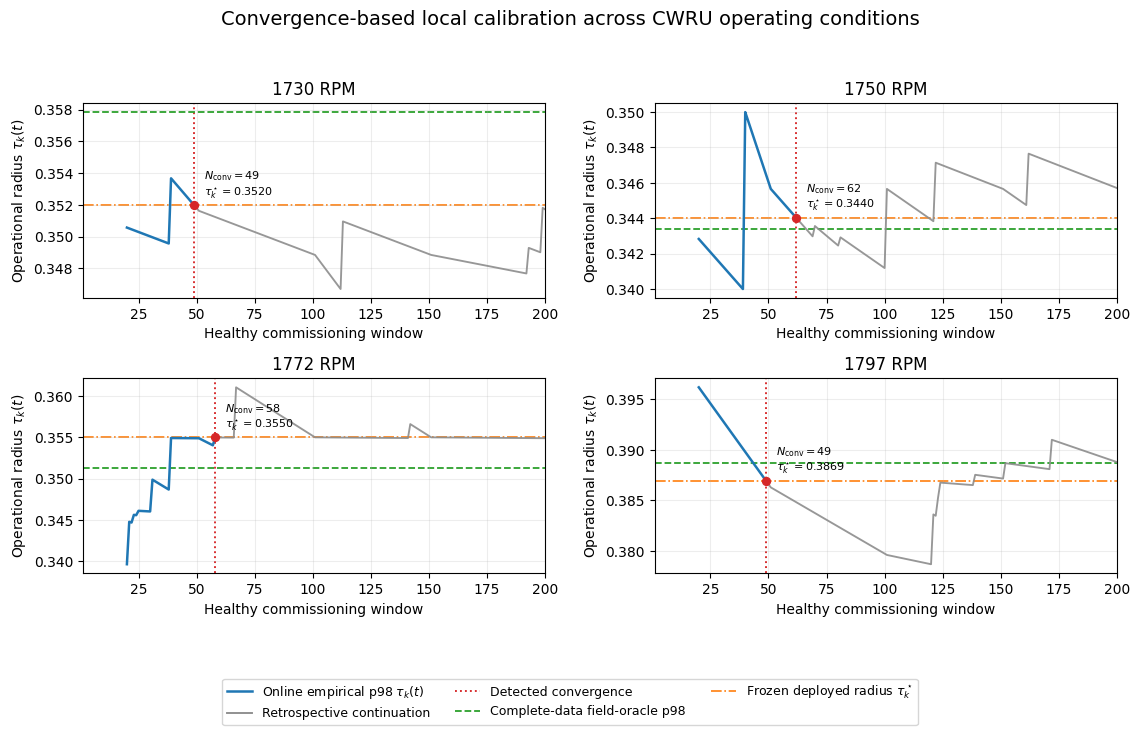

In [38]:
fig, axes = plot_tau_convergence_all(
    experiments=results,
    save_path="cwru_tau_convergence.pdf",
)

In [31]:
trace = warmup_traces[("1797", 7)]

tau_history = trace["tau_history"]

convergence_trace = operational_radius_convergence_trace(
    tau_history,
    lookback=CONVERGENCE_LOOKBACK,
)

print("Final tau:", trace["tau_online"])
print("Oracle:", trace["tau_field_oracle"])
print("Finite tau values:", np.sum(np.isfinite(tau_history)))
print("Minimum convergence statistic:", np.nanmin(convergence_trace))
print("Last 20 tau values:")
print(tau_history[-20:])
print("Last 20 convergence values:")
print(convergence_trace[-20:])

print(convergence_trace[-20:])

Final tau: 0.4022134083509445
Oracle: 0.3886467468738556
Finite tau values: 81
Minimum convergence statistic: 0.0001907306495589623
Last 20 tau values:
[0.38768541 0.39383758 0.39356764 0.3932977  0.39302776 0.39275782
 0.39248788 0.39221794 0.391948   0.40229014 0.40228246 0.40227479
 0.40226712 0.40225945 0.40225177 0.4022441  0.40223643 0.40222875
 0.40222108 0.40221341]
Last 20 convergence values:
[0.01480531 0.03158076 0.03154566 0.03151051 0.03147531 0.03144007
 0.03140478 0.03136945 0.03133407 0.0375803  0.0376518  0.02142307
 0.02210415 0.02278617 0.02346912 0.02415301 0.02483784 0.02552361
 0.02621033 0.00019073]
[0.01480531 0.03158076 0.03154566 0.03151051 0.03147531 0.03144007
 0.03140478 0.03136945 0.03133407 0.0375803  0.0376518  0.02142307
 0.02210415 0.02278617 0.02346912 0.02415301 0.02483784 0.02552361
 0.02621033 0.00019073]


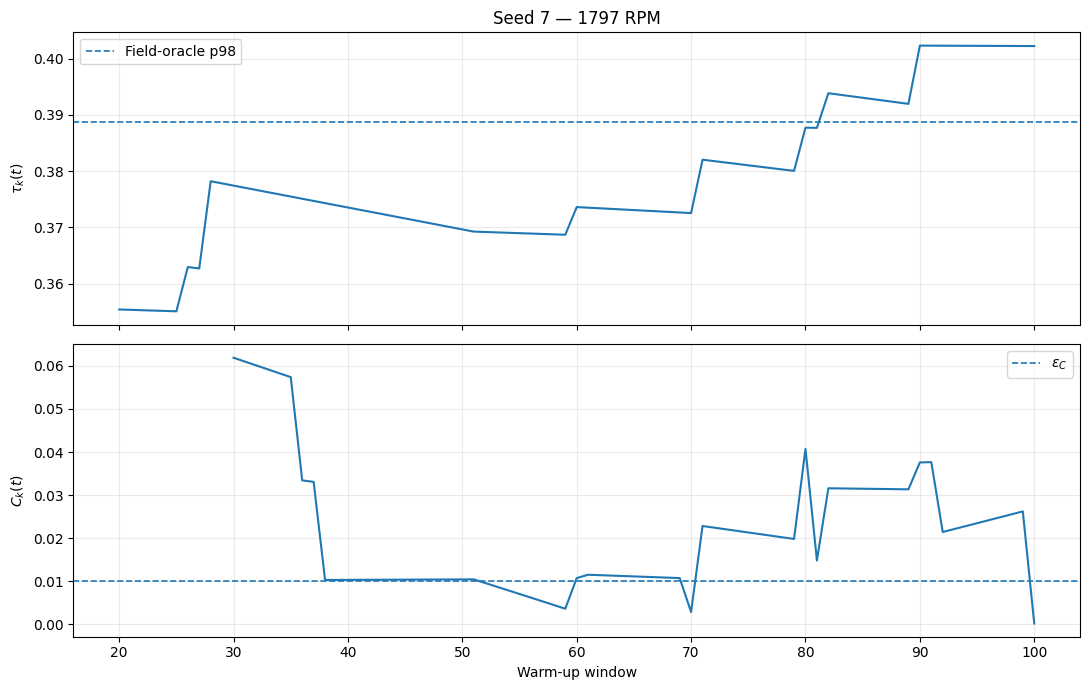

In [23]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

steps = np.arange(1, len(tau_history) + 1)

axes[0].plot(steps, tau_history, linewidth=1.5)
axes[0].axhline(
    trace["tau_field_oracle"],
    linestyle="--",
    linewidth=1.2,
    label="Field-oracle p98",
)
axes[0].set_ylabel(r"$\tau_k(t)$")
axes[0].set_title("Seed 7 — 1797 RPM")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(steps, convergence_trace, linewidth=1.5)
axes[1].axhline(
    CONVERGENCE_TOLERANCE,
    linestyle="--",
    linewidth=1.2,
    label=r"$\varepsilon_C$",
)
axes[1].set_xlabel("Warm-up window")
axes[1].set_ylabel(r"$C_k(t)$")
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()


CWRU operating condition: 1730 RPM
Normal: (485643, 1)
Ball:   (486812, 1)
Inner:  (488144, 1)
Outer:  (854807, 1)
Windows → healthy:404 ball:405 inner:406 outer:712

Thresholds
τ_MC absolute        = 0.102678
τ_field oracle p98   = 0.357836
τ_online             = 0.351960
Calibration status   = converged
Calibration samples  = 49
Operational-radius convergence detected at calibration window 49.


,bearing_id,detector,calibration,threshold_percentile,threshold,healthy_far,ball_dr,inner_race_dr,outer_race_dr,n_healthy,n_ball,n_inner_race,n_outer_race,min_calibration_size,max_calibration_size,calibration_size,calibration_status,convergence_index,convergence_window
0,1730,Shared simulator-trained AE,absolute_mc,98.0,0.102678,100.000000,100.000000,100.0,100.000000,404,405,406,712,NaN,NaN,0,not_applicable,NaN,NaN
1,1730,Shared simulator-trained AE,field_oracle,98.0,0.357836,2.227723,99.753086,100.0,99.859551,404,405,406,712,NaN,NaN,404,oracle,NaN,NaN
2,1730,Shared simulator-trained AE,online_radius,98.0,0.351960,3.712871,99.753086,100.0,100.000000,404,405,406,712,40.0,200.0,49,converged,48.0,49.0


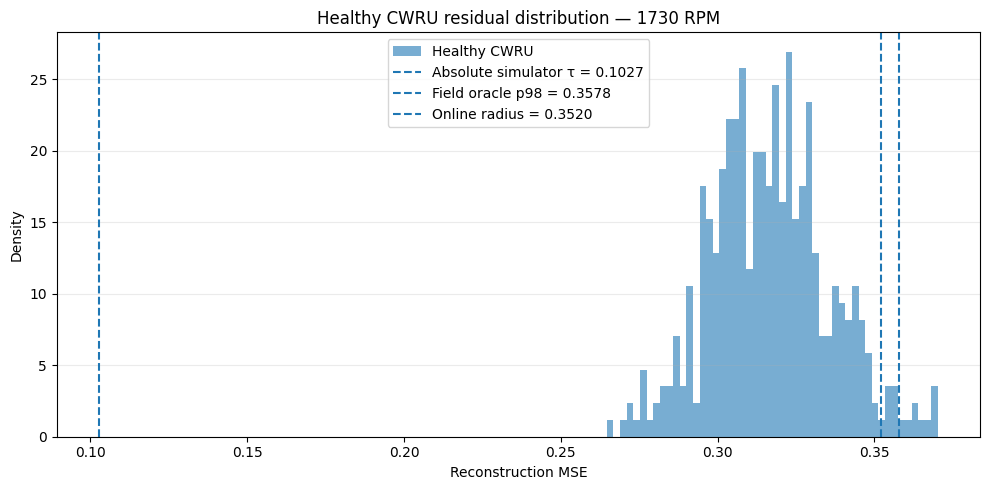

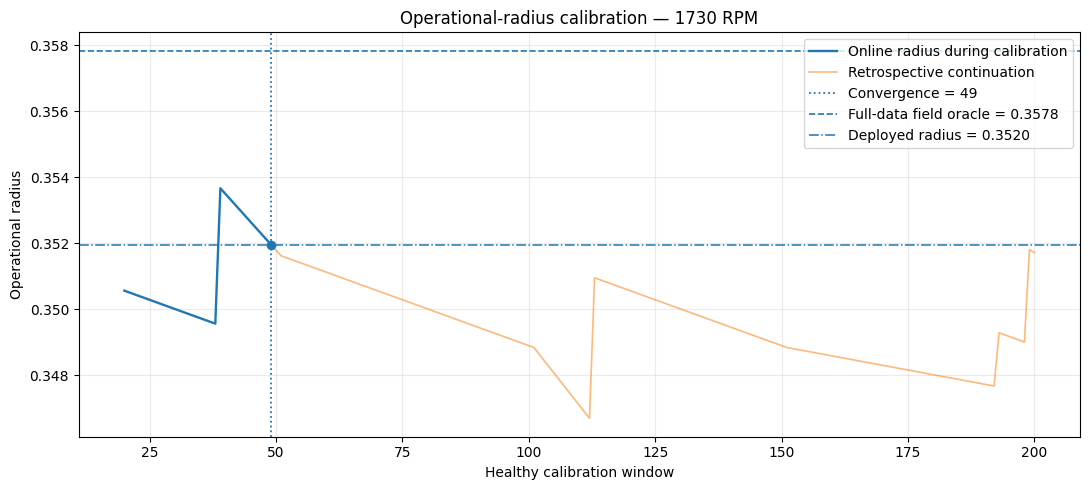

Full healthy windows: 404
Online warm-up windows: 200
Field oracle p98: 0.357836
Online radius: 0.351960

CWRU operating condition: 1750 RPM
Normal: (485063, 1)
Ball:   (486667, 1)
Inner:  (487179, 1)
Outer:  (854371, 1)
Windows → healthy:404 ball:405 inner:405 outer:711

Thresholds
τ_MC absolute        = 0.102678
τ_field oracle p98   = 0.343380
τ_online             = 0.344017
Calibration status   = converged
Calibration samples  = 62
Operational-radius convergence detected at calibration window 62.


,bearing_id,detector,calibration,threshold_percentile,threshold,healthy_far,ball_dr,inner_race_dr,outer_race_dr,n_healthy,n_ball,n_inner_race,n_outer_race,min_calibration_size,max_calibration_size,calibration_size,calibration_status,convergence_index,convergence_window
0,1750,Shared simulator-trained AE,absolute_mc,98.0,0.102678,100.000000,100.0,100.0,100.0,404,405,405,711,NaN,NaN,0,not_applicable,NaN,NaN
1,1750,Shared simulator-trained AE,field_oracle,98.0,0.343380,2.227723,100.0,100.0,100.0,404,405,405,711,NaN,NaN,404,oracle,NaN,NaN
2,1750,Shared simulator-trained AE,online_radius,98.0,0.344017,1.980198,100.0,100.0,100.0,404,405,405,711,40.0,200.0,62,converged,61.0,62.0


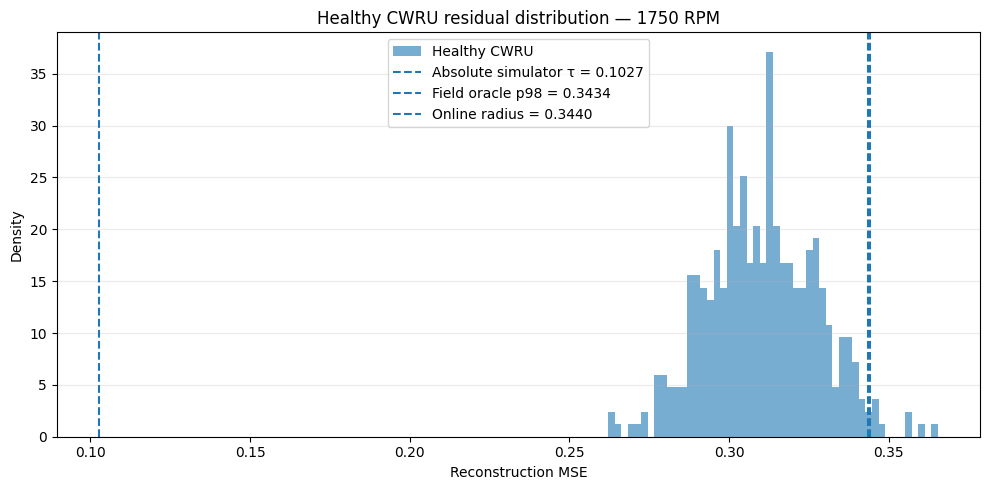

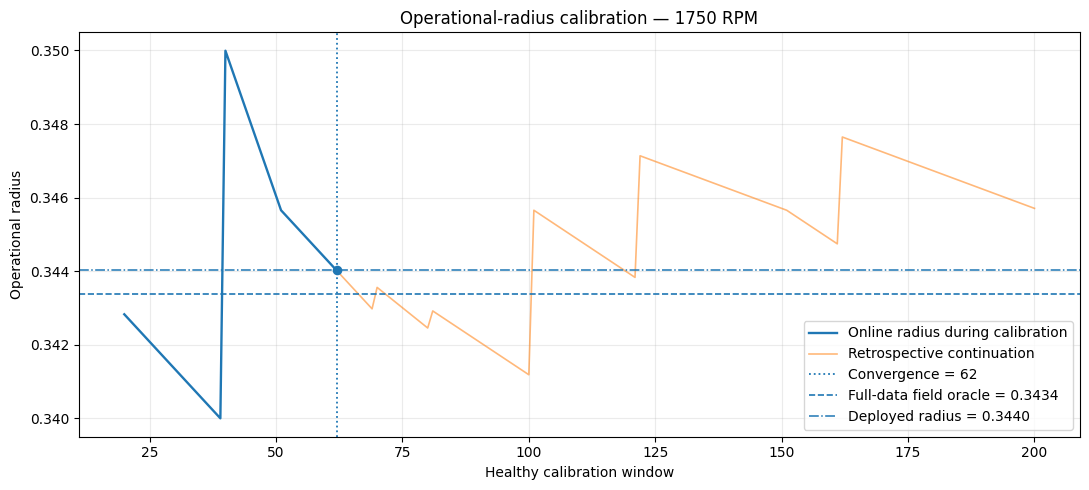

Full healthy windows: 404
Online warm-up windows: 200
Field oracle p98: 0.343380
Online radius: 0.344017

CWRU operating condition: 1772 RPM
Normal: (483903, 1)
Ball:   (486598, 1)
Inner:  (486744, 1)
Outer:  (854807, 1)
Windows → healthy:403 ball:405 inner:405 outer:712

Thresholds
τ_MC absolute        = 0.102678
τ_field oracle p98   = 0.351243
τ_online             = 0.354977
Calibration status   = converged
Calibration samples  = 58
Operational-radius convergence detected at calibration window 58.


,bearing_id,detector,calibration,threshold_percentile,threshold,healthy_far,ball_dr,inner_race_dr,outer_race_dr,n_healthy,n_ball,n_inner_race,n_outer_race,min_calibration_size,max_calibration_size,calibration_size,calibration_status,convergence_index,convergence_window
0,1772,Shared simulator-trained AE,absolute_mc,98.0,0.102678,100.000000,100.0,100.0,100.0,403,405,405,712,NaN,NaN,0,not_applicable,NaN,NaN
1,1772,Shared simulator-trained AE,field_oracle,98.0,0.351243,2.233251,100.0,100.0,100.0,403,405,405,712,NaN,NaN,403,oracle,NaN,NaN
2,1772,Shared simulator-trained AE,online_radius,98.0,0.354977,1.240695,100.0,100.0,100.0,403,405,405,712,40.0,200.0,58,converged,57.0,58.0


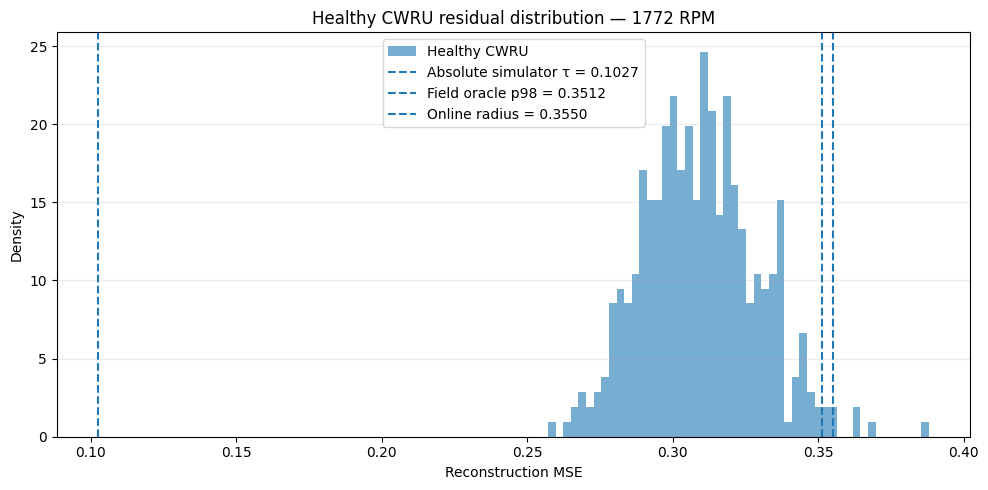

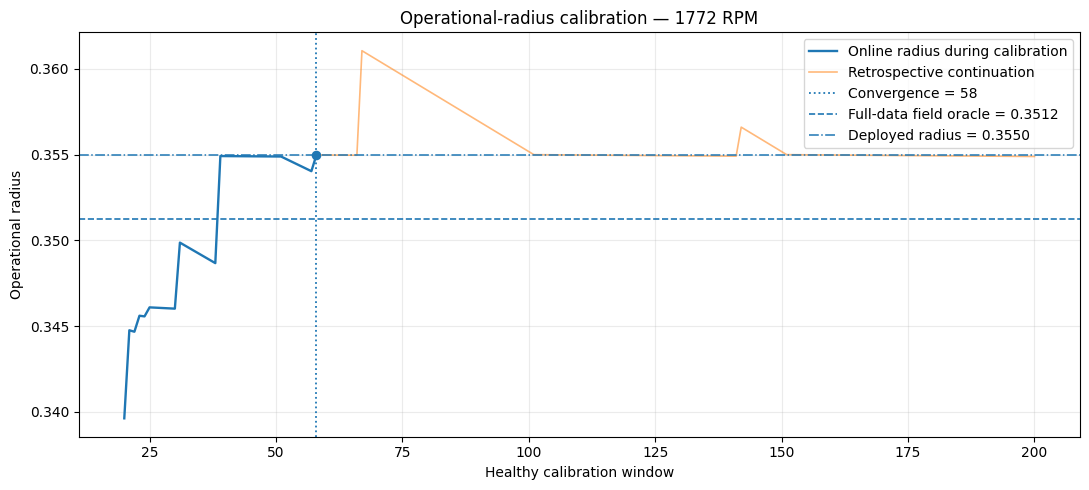

Full healthy windows: 403
Online warm-up windows: 200
Field oracle p98: 0.351243
Online radius: 0.354977

CWRU operating condition: 1797 RPM
Normal: (243938, 1)
Ball:   (487209, 1)
Inner:  (486048, 1)
Outer:  (854372, 1)
Windows → healthy:203 ball:406 inner:405 outer:711

Thresholds
τ_MC absolute        = 0.102678
τ_field oracle p98   = 0.388647
τ_online             = 0.386927
Calibration status   = converged
Calibration samples  = 49
Operational-radius convergence detected at calibration window 49.


,bearing_id,detector,calibration,threshold_percentile,threshold,healthy_far,ball_dr,inner_race_dr,outer_race_dr,n_healthy,n_ball,n_inner_race,n_outer_race,min_calibration_size,max_calibration_size,calibration_size,calibration_status,convergence_index,convergence_window
0,1797,Shared simulator-trained AE,absolute_mc,98.0,0.102678,100.000000,100.000000,100.0,100.0,203,406,405,711,NaN,NaN,0,not_applicable,NaN,NaN
1,1797,Shared simulator-trained AE,field_oracle,98.0,0.388647,2.463054,98.275862,100.0,100.0,203,406,405,711,NaN,NaN,203,oracle,NaN,NaN
2,1797,Shared simulator-trained AE,online_radius,98.0,0.386927,3.448276,98.522167,100.0,100.0,203,406,405,711,40.0,200.0,49,converged,48.0,49.0


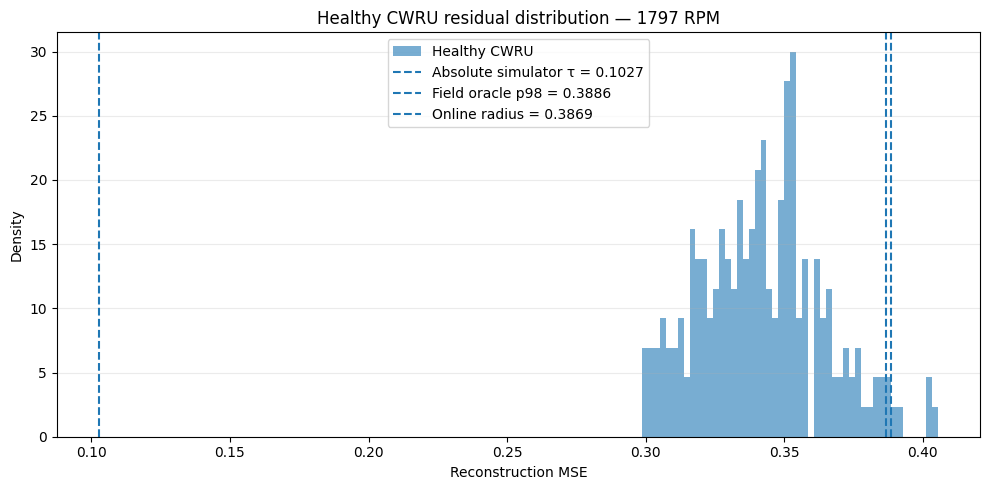

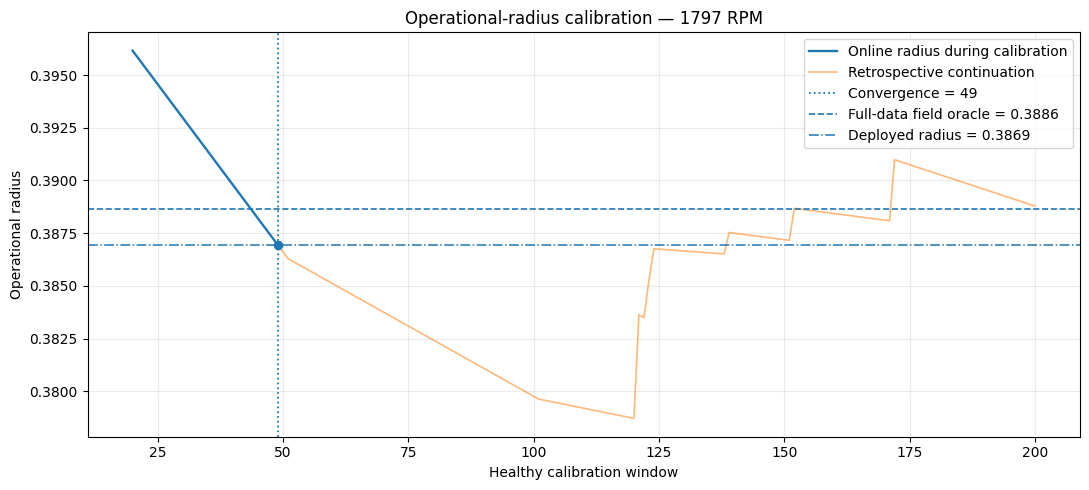

Full healthy windows: 203
Online warm-up windows: 200
Field oracle p98: 0.388647
Online radius: 0.386927


In [32]:
results = {}

for bearing_id in BEARING_IDS:

    result = run_experiment(
        bearing_id,
        target_percentile=TARGET_PERCENTILE,
        min_calibration_size=MIN_CALIBRATION_SIZE,
        max_calibration_size=MAX_CALIBRATION_SIZE,
        min_warmup_samples=MIN_WARMUP_SAMPLES,
        convergence_lookback=CONVERGENCE_LOOKBACK,
        convergence_tolerance=CONVERGENCE_TOLERANCE,
        convergence_consecutive=CONVERGENCE_CONSECUTIVE,
    )

    results[str(bearing_id)] = result

    plot_experiment(result)

In [28]:
for rpm, result in results.items():
    row = result["results_table"]
    online = row[row["calibration"] == "online_radius"]

    print(
        rpm,
        "FAR =", online["healthy_far"].iloc[0],
        "tau_online =", result["tau_online"],
        "tau_oracle =", result["tau_field_oracle"],
        "conv =", result["convergence_window"],
    )

1730 FAR = 3.7128712871287126 tau_online = 0.3519604027271271 tau_oracle = 0.3578356736898422 conv = 49
1750 FAR = 1.9801980198019802 tau_online = 0.34401746034622194 tau_oracle = 0.34337959468364715 conv = 62
1772 FAR = 1.240694789081886 tau_online = 0.35497679650783537 tau_oracle = 0.35124344110488886 conv = 58
1797 FAR = 3.4482758620689653 tau_online = 0.3869269096851349 tau_oracle = 0.3886467492580414 conv = 49


In [29]:
for rpm, result in results.items():
    if result["calibration_status"] != "converged":
        continue

    n_conv = int(result["calibration_size"])
    post_calibration_healthy = result["mse_healthy"][n_conv:]

    post_far = 100.0 * np.mean(
        post_calibration_healthy > result["tau_online"]
    )

    print(
        rpm,
        f"post-calibration FAR = {post_far:.2f}%"
    )

1730 post-calibration FAR = 3.94%
1750 post-calibration FAR = 1.75%
1772 post-calibration FAR = 0.87%
1797 post-calibration FAR = 3.90%


In [ ]:
# =====================================================================
# EDGE FOOTPRINT MEASUREMENT
# Requires: shared_ae, shared_sig_len
# =====================================================================

import os
import time
import tempfile


# ---------------------------------------------------------------------
# 1. Parameter and raw-weight size
# ---------------------------------------------------------------------

parameter_count = shared_ae.count_params()

float32_weight_bytes = parameter_count * np.dtype(np.float32).itemsize
float32_weight_mb = float32_weight_bytes / 1_000_000
float32_weight_mib = float32_weight_bytes / (1024 ** 2)


# ---------------------------------------------------------------------
# 2. Exact serialized model size
# Save without optimizer state, because deployment uses inference only.
# ---------------------------------------------------------------------

with tempfile.TemporaryDirectory() as tmpdir:
    keras_path = os.path.join(tmpdir, "shared_oem_model.keras")

    # Clone/compile state is not required for inference.
    shared_ae.save(
        keras_path,
        include_optimizer=False,
    )

    serialized_bytes = os.path.getsize(keras_path)
    serialized_mb = serialized_bytes / 1_000_000
    serialized_mib = serialized_bytes / (1024 ** 2)


# ---------------------------------------------------------------------
# 3. Local calibration-state size
# Compact implementation: 100 float32 residuals plus a few scalar values.
# ---------------------------------------------------------------------

LOCAL_BUFFER_LENGTH = 100

residual_buffer_bytes = (
    LOCAL_BUFFER_LENGTH * np.dtype(np.float32).itemsize
)

# Example compact scalar state:
# current tau, previous tau, percentile, tolerance,
# convergence counter, state flag, and sample counter.
estimated_scalar_state_bytes = (
    4 * np.dtype(np.float32).itemsize
    + 3 * np.dtype(np.int32).itemsize
)

local_state_bytes = (
    residual_buffer_bytes + estimated_scalar_state_bytes
)


# ---------------------------------------------------------------------
# 4. Batch-1 CPU inference latency
# Use a real-shaped input. shared_ae is kept fixed.
# ---------------------------------------------------------------------

benchmark_input = np.zeros(
    (1, shared_sig_len, 1),
    dtype=np.float32,
)

benchmark_tensor = tf.convert_to_tensor(benchmark_input)

# Warm-up: TensorFlow tracing, memory allocation, and caches
N_WARMUP = 50
for _ in range(N_WARMUP):
    _ = shared_ae(
        benchmark_tensor,
        training=False,
    )

# Timed runs
N_RUNS = 500
latencies_ms = []

for _ in range(N_RUNS):
    start = time.perf_counter()

    output = shared_ae(
        benchmark_tensor,
        training=False,
    )

    # Force completion before stopping the clock
    _ = output.numpy()

    elapsed_ms = (
        time.perf_counter() - start
    ) * 1000.0

    latencies_ms.append(elapsed_ms)

latencies_ms = np.asarray(latencies_ms)

latency_median_ms = float(np.median(latencies_ms))
latency_mean_ms = float(np.mean(latencies_ms))
latency_std_ms = float(np.std(latencies_ms, ddof=1))
latency_p95_ms = float(np.percentile(latencies_ms, 95))


# ---------------------------------------------------------------------
# 5. Results
# ---------------------------------------------------------------------

edge_footprint = pd.DataFrame(
    [
        {
            "metric": "Model parameters",
            "value": f"{parameter_count:,}",
        },
        {
            "metric": "Raw float32 weight size",
            "value": (
                f"{float32_weight_mb:.2f} MB "
                f"({float32_weight_mib:.2f} MiB)"
            ),
        },
        {
            "metric": "Serialized .keras size",
            "value": (
                f"{serialized_mb:.2f} MB "
                f"({serialized_mib:.2f} MiB)"
            ),
        },
        {
            "metric": "CPU latency, median",
            "value": f"{latency_median_ms:.3f} ms/window",
        },
        {
            "metric": "CPU latency, mean ± std",
            "value": (
                f"{latency_mean_ms:.3f} ± "
                f"{latency_std_ms:.3f} ms/window"
            ),
        },
        {
            "metric": "CPU latency, p95",
            "value": f"{latency_p95_ms:.3f} ms/window",
        },
        {
            "metric": "Local residual-buffer length",
            "value": str(LOCAL_BUFFER_LENGTH),
        },
        {
            "metric": "Residual-buffer memory",
            "value": f"{residual_buffer_bytes} bytes",
        },
        {
            "metric": "Estimated compact local state",
            "value": (
                f"{local_state_bytes} bytes "
                f"(< 1 kB)"
            ),
        },
        {
            "metric": "Per-asset model training",
            "value": "None",
        },
        {
            "metric": "Fault labels required",
            "value": "None",
        },
    ]
)

display(edge_footprint)